# Model architecture — Station-MAE transformer vs LSTM baseline

Layer-by-layer structure, tensor shapes and parameter counts for both models.

Two complementary tools:

| tool | gives | needs |
|---|---|---|
| **`pytorch_lightning.utilities.model_summary.ModelSummary`** | Lightning's own summary: module tree, type, parameter counts, train/eval mode. Adds **In sizes / Out sizes** when `example_input_array` is set. | a `LightningModule` |
| **`torchinfo.summary()`** | per-layer **input → output shapes**, parameter counts, and estimated memory / mult-adds | any `nn.Module` + example input |

`ModelSummary` is what the `Trainer` prints automatically at the start of a run.

In [1]:
# ── Setup ────────────────────────────────────────────────────────────────────
import os, sys
# ── Project bootstrap ────────────────────────────────────────────────────────
# This notebook lives in notebooks/ but reads checkpoints/, test_results/ and
# report/ from the project root, and imports data/engine/model from src/.
# Re-running this cell is safe (it only climbs out of notebooks/ once).
import os, sys
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
PROJ = os.getcwd()
if os.path.join(PROJ, "src") not in sys.path:
    sys.path.insert(0, os.path.join(PROJ, "src"))
import torch, torch.nn as nn
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import pytorch_lightning as pl
from pytorch_lightning.utilities.model_summary import ModelSummary

try:
    from torchinfo import summary as torchinfo_summary
    HAS_TORCHINFO = True
except ImportError:
    HAS_TORCHINFO = False
    print("torchinfo not installed →  pip install torchinfo   (shape tracing will be skipped)")

# ── Trained configuration (run_full_cloud.sh · tw6-d1024-v9 / v11 / v12) ────
W, N, V, VT = 72, 155, 6, 5          # window, stations, input vars, target vars
K            = 13                    # horizons: 0, 3, …, 36 steps (0–6 h)
CFG = dict(d_model=1024, enc_heads=16, enc_layers=8, dec_heads=16, dec_layers=2,
           mlp_ratio=4.0, dropout=0.0, mask_ratio=0.5, temporal_window=6,
           cross_attention_decoder=True,
           window_size=W)
BATCH = 1        # shape tracing only — keep small, the forward is real
print(f"torch {torch.__version__} | lightning {pl.__version__} | torchinfo {HAS_TORCHINFO}")
print(f"config: {CFG}")

torchinfo not installed →  pip install torchinfo   (shape tracing will be skipped)
torch 2.11.0 | lightning 2.6.1 | torchinfo False
config: {'d_model': 1024, 'enc_heads': 16, 'enc_layers': 8, 'dec_heads': 16, 'dec_layers': 2, 'mlp_ratio': 4.0, 'dropout': 0.0, 'mask_ratio': 0.5, 'temporal_window': 6, 'cross_attention_decoder': True, 'window_size': 72}


## 1. Station-MAE transformer

In [2]:
# ── Build the transformer at the trained configuration ──────────────────────
from model.mae import StationMAE
from model.lightning_module import StationMAELightning

mae = StationMAE(**CFG)
lit = StationMAELightning(model=mae, cfg={"lr":1e-4, "epochs":100})
print(f"Total trainable parameters: {mae.count_parameters():,}")

Total trainable parameters: 139,793,413


In [3]:
# ── Lightning ModelSummary — top level then full depth ──────────────────────
print(ModelSummary(lit, max_depth=1))       # what Trainer prints by default

  | Name  | Type       | Params | Mode  | FLOPs
-----------------------------------------------------
0 | model | StationMAE | 139 M  | train | 0    
-----------------------------------------------------
139 M     Trainable params
0         Non-trainable params
139 M     Total params
559.174   Total estimated model params size (MB)
174       Modules in train mode
0         Modules in eval mode
0         Total Flops


In [4]:
# ── Deeper view: one level into encoder / decoder ───────────────────────────
print(ModelSummary(lit, max_depth=3))

   | Name                       | Type                | Params | Mode  | FLOPs
------------------------------------------------------------------------------------
0  | model                      | StationMAE          | 139 M  | train | 0    
1  | model.encoder              | StationMAEEncoder   | 105 M  | train | 0    
2  | model.encoder.var_proj     | VariableProjection  | 18.4 K | train | 0    
3  | model.encoder.pos_emb      | PositionalEmbedding | 1.1 M  | train | 0    
4  | model.encoder.station_emb  | StationEmbedding    | 1.1 M  | train | 0    
5  | model.encoder.temporal_emb | TemporalEmbedding   | 1.1 M  | train | 0    
6  | model.encoder.step_emb     | StepIndexEmbedding  | 1.1 M  | train | 0    
7  | model.encoder.token_norm   | LayerNorm           | 2.0 K  | train | 0    
8  | model.encoder.blocks       | ModuleList          | 100 M  | train | 0    
9  | model.encoder.norm         | LayerNorm           | 2.0 K  | train | 0    
10 | model.decoder              | StationMAEDe

In [5]:
# ── torchinfo: per-layer input → output shapes ──────────────────────────────
# StationMAE.forward_multi_delta takes 8 tensors, so wrap it in a thin module
# exposing a single forward() that torchinfo can trace.
class MAETrace(nn.Module):
    def __init__(self, m): super().__init__(); self.m = m
    def forward(self, x, x_mask, spatial, x_hours, y, y_mask, y_hours, delta_steps):
        return self.m.forward_multi_delta(x, x_mask, spatial, x_hours,
                                          y, y_mask, y_hours, delta_steps)[1]

grid = torch.arange(0, 37, 3)                                   # (K,)
example = [
    torch.randn(BATCH, W, N, V),        # x
    torch.ones (BATCH, W, N, V),        # x_mask
    torch.randn(N, 15),                 # spatial
    torch.rand (BATCH, W) * 1e5,        # x_hours
    torch.randn(BATCH, K, N, V),        # y
    torch.ones (BATCH, K, N, V),        # y_mask
    torch.rand (BATCH, K) * 1e5,        # y_hours
    grid.unsqueeze(0).repeat(BATCH, 1), # delta_steps (B, K)
]
if HAS_TORCHINFO:
    print(torchinfo_summary(MAETrace(mae), input_data=example, depth=3,
                            col_names=("input_size","output_size","num_params"),
                            row_settings=("var_names",), verbose=1))
else:
    mae.eval()
    with torch.no_grad():
        out = MAETrace(mae)(*example)
    print("torchinfo unavailable — forward output shape:", tuple(out.shape))

torchinfo unavailable — forward output shape: (1, 13, 155, 5)


In [6]:
# ── Data flow, stage by stage (the shapes that matter) ──────────────────────
n_vis = int(N * (1 - CFG["mask_ratio"]))
tw    = CFG["temporal_window"]
flow = [
    ("input x",                f"({BATCH}, {W}, {N}, {V})",            "raw window, 12 h @ 10 min"),
    ("tokens (5 embeddings summed)", f"({BATCH}, {W}, {N}, {CFG['d_model']})", "var + pos + station + temporal + step"),
    ("after station masking",  f"({BATCH}, {W}, {n_vis}, {CFG['d_model']})", f"{int(CFG['mask_ratio']*100)} % of stations hidden"),
    ("encoder input (flat)",   f"({BATCH}, {W*n_vis}, {CFG['d_model']})",   f"{W*n_vis:,} tokens"),
    ("attention window",       f"({BATCH}×{W//tw}, {tw*n_vis}, {CFG['d_model']})", f"{tw} steps × {n_vis} stations = {tw*n_vis} tokens/chunk"),
    ("encoder output",         f"({BATCH}, {W*n_vis}, {CFG['d_model']})",   "context for cross-attention"),
    ("decoder queries",        f"({BATCH}, {N*K}, {CFG['d_model']})",       f"{N} stations × {K} horizons = {N*K:,}"),
    ("head output",            f"({BATCH}, {K}, {N}, {VT})",           "5 target variables"),
]
display(pd.DataFrame(flow, columns=["stage", "shape", "note"]))

,stage,shape,note
0,input x,"(1, 72, 155, 6)","raw window, 12 h @ 10 min"
1,tokens (5 embeddings summed),"(1, 72, 155, 1024)",var + pos + station + temporal + step
2,after station masking,"(1, 72, 77, 1024)",50 % of stations hidden
3,encoder input (flat),"(1, 5544, 1024)","5,544 tokens"
4,attention window,"(1×12, 462, 1024)",6 steps × 77 stations = 462 tokens/chunk
5,encoder output,"(1, 5544, 1024)",context for cross-attention
6,decoder queries,"(1, 2015, 1024)","155 stations × 13 horizons = 2,015"
7,head output,"(1, 13, 155, 5)",5 target variables


,module,params,%
6,encoder.blocks,"100,769,792",72.1%
14,decoder.blocks,"33,597,440",24.0%
8,decoder.pos_emb,"1,085,440",0.8%
3,encoder.temporal_emb,"1,085,440",0.8%
4,encoder.step_emb,"1,085,440",0.8%
12,decoder.step_emb,"1,085,440",0.8%
1,encoder.pos_emb,"1,085,440",0.8%
10,decoder.temporal_emb,"1,085,440",0.8%
11,decoder.delta_emb,"1,069,056",0.8%
2,encoder.station_emb,"1,065,984",0.8%


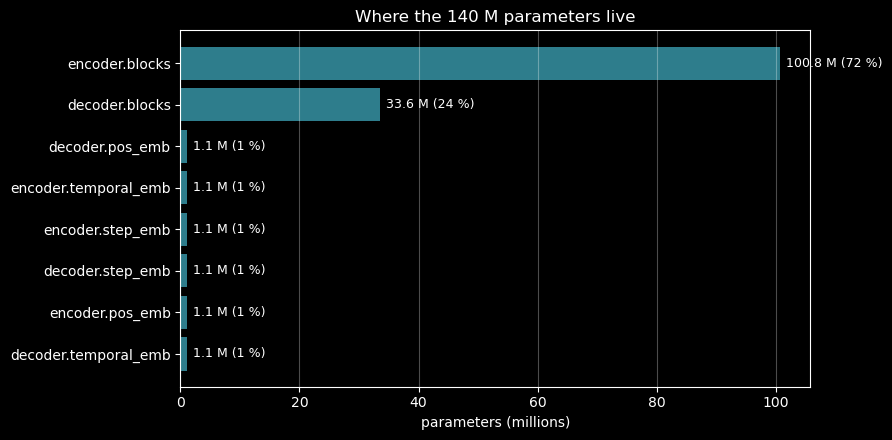

In [7]:
# ── Parameter breakdown ─────────────────────────────────────────────────────
def breakdown(model, prefix=""):
    rows = []
    for name, mod in model.named_children():
        p = sum(q.numel() for q in mod.parameters() if q.requires_grad)
        if p: rows.append((prefix + name, p))
    return rows

rows = breakdown(mae.encoder, "encoder.") + breakdown(mae.decoder, "decoder.")
tot  = mae.count_parameters()
df   = pd.DataFrame(rows, columns=["module", "params"]).sort_values("params", ascending=False)
df["%"] = 100 * df["params"] / tot
display(df.head(12).style.format({"params":"{:,.0f}", "%":"{:.1f}%"})
        .set_caption(f"Station-MAE — {tot:,} trainable parameters"))

fig, ax = plt.subplots(figsize=(9, 4.5))
top = df.head(8).iloc[::-1]
ax.barh(top["module"], top["params"] / 1e6, color="#2E7D8C")
for y, (v, pc) in enumerate(zip(top["params"], top["%"])):
    ax.text(v/1e6 + 1, y, f"{v/1e6:.1f} M ({pc:.0f} %)", va="center", fontsize=9)
ax.set_xlabel("parameters (millions)")
ax.set_title(f"Where the {tot/1e6:.0f} M parameters live")
ax.grid(axis="x", alpha=0.3); plt.tight_layout(); plt.show()

## 2. LSTM baseline

Simpler by construction: the station axis is folded into the batch, so a single
tensor goes in. That means `example_input_array` works directly and `ModelSummary`
prints **In sizes / Out sizes** without any wrapper.

In [8]:
# ── Build the LSTM at its trained configuration ─────────────────────────────
from model.lstm_baseline import StationLSTM, StationLSTMLightning

LCFG = dict(num_vars=V, num_target_vars=VT, hidden=1024, num_layers=3,
            dropout=0.1, num_horizons=K, use_mask_feature=True)
lstm = StationLSTM(**LCFG)
lit_lstm = StationLSTMLightning(model=lstm, cfg={"lr":1e-3, "epochs":60})

# example_input_array → ModelSummary gains In/Out size columns.
# The LSTM sees (batch × stations, W, 2·V) because mask features are concatenated.
in_dim = V * (2 if LCFG["use_mask_feature"] else 1)
lit_lstm.example_input_array = torch.randn(BATCH * N, W, in_dim)
print(f"Total trainable parameters: {lstm.count_parameters():,}")
print(f"example input: {tuple(lit_lstm.example_input_array.shape)}  "
      f"({BATCH} window × {N} stations folded into batch)")

Total trainable parameters: 21,111,873
example input: (155, 72, 12)  (1 window × 155 stations folded into batch)


In [9]:
# ── ModelSummary WITH shapes (example_input_array is set) ──────────────────
# StationLSTMLightning has no forward(); give it one so the summary can trace.
if not hasattr(type(lit_lstm), "_forward_patched"):
    type(lit_lstm).forward = lambda self, x: self.model(x)
    type(lit_lstm)._forward_patched = True
print(ModelSummary(lit_lstm, max_depth=2))

  | Name       | Type        | Params | Mode  | FLOPs  | In sizes      | Out sizes                                          
----------------------------------------------------------------------------------------------------------------------------------
0 | model      | StationLSTM | 21.1 M | train | 469 B  | [155, 72, 12] | [155, 13, 5]                                       
1 | model.lstm | LSTM        | 21.0 M | train | 469 B  | [155, 72, 12] | [[155, 72, 1024], [[3, 155, 1024], [3, 155, 1024]]]
2 | model.head | Linear      | 66.6 K | train | 20.6 M | [155, 1024]   | [155, 65]                                          
----------------------------------------------------------------------------------------------------------------------------------
21.1 M    Trainable params
0         Non-trainable params
21.1 M    Total params
84.447    Total estimated model params size (MB)
3         Modules in train mode
0         Modules in eval mode
469 B     Total Flops


In [10]:
# ── torchinfo for the LSTM ──────────────────────────────────────────────────
if HAS_TORCHINFO:
    print(torchinfo_summary(lstm, input_data=lit_lstm.example_input_array, depth=2,
                            col_names=("input_size","output_size","num_params"),
                            row_settings=("var_names",), verbose=1))
else:
    print("torchinfo unavailable — output shape:",
          tuple(lstm(lit_lstm.example_input_array).shape))

torchinfo unavailable — output shape: (155, 13, 5)


## 3. Side by side

In [11]:
# ── Comparison table ────────────────────────────────────────────────────────
enc_p = sum(p.numel() for p in mae.encoder.parameters() if p.requires_grad)
dec_p = sum(p.numel() for p in mae.decoder.parameters() if p.requires_grad)
cmp = pd.DataFrame({
    "Station-MAE (transformer)": {
        "total parameters":      f"{mae.count_parameters():,}",
        "encoder / decoder":     f"{enc_p/1e6:.1f} M / {dec_p/1e6:.1f} M",
        "input":                 f"(B, {W}, {N}, {V}) — whole network at once",
        "output":                f"(B, {K}, {N}, {VT})",
        "tokens processed":      f"{W*int(N*0.5):,} (after 50 % station masking)",
        "sees other stations":   "yes — attention across stations",
        "station masking":       "yes — 50 % hidden from the encoder",
        "positional info":       "additive Fourier embeddings, summed into token",
    },
    "LSTM baseline": {
        "total parameters":      f"{lstm.count_parameters():,}",
        "encoder / decoder":     "— (3 LSTM layers + linear head)",
        "input":                 f"(B×{N}, {W}, {in_dim}) — one station at a time",
        "output":                f"(B×{N}, {K}, {VT})",
        "tokens processed":      f"{W} steps per station sequence",
        "sees other stations":   "no — spatially blind",
        "station masking":       "no — pure forecaster",
        "positional info":       "implicit in the recurrence",
    },
})
display(cmp)

ratio = mae.count_parameters() / lstm.count_parameters()
print(f"\nThe transformer has {ratio:.1f}× the parameters of the LSTM.")

,Station-MAE (transformer),LSTM baseline
total parameters,"139,793,413","21,111,873"
encoder / decoder,105.1 M / 39.0 M,— (3 LSTM layers + linear head)
input,"(B, 72, 155, 6) — whole network at once","(B×155, 72, 12) — one station at a time"
output,"(B, 13, 155, 5)","(B×155, 13, 5)"
tokens processed,"5,544 (after 50 % station masking)",72 steps per station sequence
sees other stations,yes — attention across stations,no — spatially blind
station masking,yes — 50 % hidden from the encoder,no — pure forecaster
positional info,"additive Fourier embeddings, summed into token",implicit in the recurrence



The transformer has 6.6× the parameters of the LSTM.


In [12]:
# ── Save summaries for the report ───────────────────────────────────────────
os.makedirs("report", exist_ok=True)
with open("report/model_summary_mae.txt", "w") as f:
    f.write(str(ModelSummary(lit, max_depth=3)))
with open("report/model_summary_lstm.txt", "w") as f:
    f.write(str(ModelSummary(lit_lstm, max_depth=2)))
df.to_csv("report/mae_parameter_breakdown.csv", index=False)
print("wrote report/model_summary_mae.txt, model_summary_lstm.txt, mae_parameter_breakdown.csv")

wrote report/model_summary_mae.txt, model_summary_lstm.txt, mae_parameter_breakdown.csv
